In [54]:
from langgraph.graph import StateGraph, START, END 
from langchain_openai import ChatOpenAI 
from typing import TypedDict , Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [55]:
load_dotenv()

True

In [56]:
model = ChatOpenAI(model='gpt-4o-mini')


In [57]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive" , "negative"] = Field(description=" sentiment of the review")
    

In [58]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug" , "Support" , "other"] = Field(description="The category of issue mentioned in the review")
    tone: Literal["angry","frustrated", "disappointed","calm"] = Field(description="The emotional tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent or critical the issue appears to be")

In [59]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [ ]:
prompt='What is the sentiment of the following review - The Software is too bad'
structured_model.invoke(prompt).sentiment

In [17]:
# from this we are starting to make the graph first we define state


In [69]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive" , "negative"]
    diagnosis :dict
    response: str

In [74]:
def find_sentiment (state : ReviewState):
    prompt = f'For the following review find out the sentiment\n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment
    
    return {'sentiment' : sentiment}


# for to check condition condition function we creted 
def check_sentiment(state : ReviewState) ->Literal["positive_response", "run_diagonsis"]:
    
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagonsis'
    
   

In [75]:
def positive_response(state : ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n {state["review"]}
    Also, Kindly ask the user to leave feedback on our website.
    """
    response = model.invoke(prompt).content
    
    return {'response' : response}

In [76]:
def run_diagonsis(state : ReviewState):
    prompt = f""" Diagnose this negative review:\n\n{state['review']}\n
    Return issue_Type , tone  and urgency
    """
    response = structured_model2.invoke(prompt)
    
    return {'diagnosis' : response.model_dump()}

# this model_dump() convert that reponse object into the dictionary  and stored in the diagonosis key of the state dictionar


# negative review response function

def negative_response(state : ReviewState):
    diagnosis = state['diagnosis']
    
    prompt = f"""You ae a support assistent.
    The user has a '{diagnosis['issue_type']}' issue . sounded '{diagnosis['tone']}' and the urgency is '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response = model.invoke(prompt).content
    
    return {'response' : response}

In [ ]:
# genrating the graph for the review reply workflow
graph = StateGraph(ReviewState)

# nodes
graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagonsis',run_diagonsis)
graph.add_node('negative_response',negative_response)

# edges
graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)

graph.add_edge('positive_response',END)

graph.add_edge('run_diagonsis','negative_response')
graph.add_edge('negative_response',END)

workflow = graph.compile()



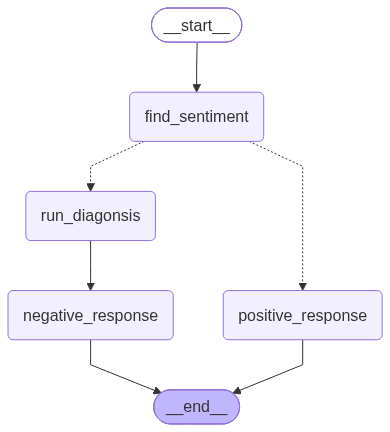

In [78]:
workflow

In [ ]:
# execute workflow

initial_state = {
    
    'review' : 'The product was really good '
    
}

workflow.invoke(initial_state)

In [ ]:
# STEP 6: Test the Workflow
# ============================================
# Test with positive review
positive_review = {
'review': """I'vebeenusingthisapp for abouta month, and Imustsaythe
userinterface is incrediblyclean and intuitive.Everything is exactly
where you'd expect it to be. It'sraretofindsomethingthatjustworks
withoutneedingatutorial.Greatjobtothedesignteam!"""
}
print("=" * 60)
print("POSITIVEREVIEWTEST")
print("=" * 60)
result_positive = workflow.invoke(positive_review)
print(f"Sentiment:{result_positive['sentiment']}")
print(f"Response:{result_positive['response']}")


In [ ]:
# Test with negative review
negative_review = {
'review': """I've been trying to log in for over an hour now, and the app
keeps freezing on the authentication screen. I even tried reinstalling it,
but no luck. This kind of bug is unacceptable, especially when it affects
basic functionality."""
}
print("\n" + "=" * 60)
print("NEGATIVE REVIEW TEST")
print("=" * 60)
result_negative = workflow.invoke(negative_review)
print(f"Sentiment: {result_negative['sentiment']}")
print(f"Diagnosis: {result_negative['diagnosis']}")
print(f"Response: {result_negative['response']}")